In [2]:
import pandas as pd 
from tensorflow.keras.layers import Dense, Dropout, Activation

from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam 

crime_data = pd.read_csv('Datasets/crimeSTATS.csv')
crime_data[1:10]

,total_crime_reported_per_1_million_res,annual_police_funding_per_res,%_high_school_25yearsPlus,%_16_to_19_not_in_HS,%_18_to_24_in_college,%_college_degree
1,494,32,72,11,43,18
2,643,57,70,18,16,16
3,341,31,71,11,25,19
4,773,67,72,9,29,24
5,603,25,68,8,32,15
6,484,34,68,12,24,14
7,546,33,62,13,28,11
8,424,36,69,7,25,12
9,548,31,66,9,58,15


In [3]:
# Set Feature & Targets
X = crime_data.drop(['total_crime_reported_per_1_million_res'], axis=1).values 
Y = crime_data[['total_crime_reported_per_1_million_res']].values

from sklearn.model_selection import train_test_split 
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=25)


# Create model
def create_model(learning_rate, dropout_rate):
    model = Sequential()
    model.add(Dense(100, input_dim=X_train.shape[1], activation='relu'))
    model.add(Dropout(dropout_rate))
    model.add(Dense(50, activation='relu'))
    model.add(Dropout(dropout_rate))
    model.add(Dense(25, activation='relu'))
    model.add(Dropout(dropout_rate))
    model.add(Dense(1))

    adam = Adam(lr=learning_rate)

    model.compile(loss='mean_squared_error', optimizer=adam, metrics=['mae'])
    return model 
    
# Model Parameters 
epochs = 100
learning_rate = 0.01
dropout_rate = 0.02


# Execute and Run the Model
model = create_model(learning_rate, dropout_rate)
model_history = model.fit(X_train, Y_train, batch_size=1, epochs=epochs, validation_split=0.2, verbose=10)


Epoch 1/100


c:\Python\Python310\lib\site-packages\keras\optimizers\optimizer_v2\adam.py:114: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


Epoch 2/100
Epoch 3/100
Epoch 4/100
Epoch 5/100
Epoch 6/100
Epoch 7/100
Epoch 8/100
Epoch 9/100
Epoch 10/100
Epoch 11/100
Epoch 12/100
Epoch 13/100
Epoch 14/100
Epoch 15/100
Epoch 16/100
Epoch 17/100
Epoch 18/100
Epoch 19/100
Epoch 20/100
Epoch 21/100
Epoch 22/100
Epoch 23/100
Epoch 24/100
Epoch 25/100
Epoch 26/100
Epoch 27/100
Epoch 28/100
Epoch 29/100
Epoch 30/100
Epoch 31/100
Epoch 32/100
Epoch 33/100
Epoch 34/100
Epoch 35/100
Epoch 36/100
Epoch 37/100
Epoch 38/100
Epoch 39/100
Epoch 40/100
Epoch 41/100
Epoch 42/100
Epoch 43/100
Epoch 44/100
Epoch 45/100
Epoch 46/100
Epoch 47/100
Epoch 48/100
Epoch 49/100
Epoch 50/100
Epoch 51/100
Epoch 52/100
Epoch 53/100
Epoch 54/100
Epoch 55/100
Epoch 56/100
Epoch 57/100
Epoch 58/100
Epoch 59/100
Epoch 60/100
Epoch 61/100
Epoch 62/100
Epoch 63/100
Epoch 64/100
Epoch 65/100
Epoch 66/100
Epoch 67/100
Epoch 68/100
Epoch 69/100
Epoch 70/100
Epoch 71/100
Epoch 72/100
Epoch 73/100
Epoch 74/100
Epoch 75/100
Epoch 76/100
Epoch 77/100
Epoch 78/100
Epoch 7

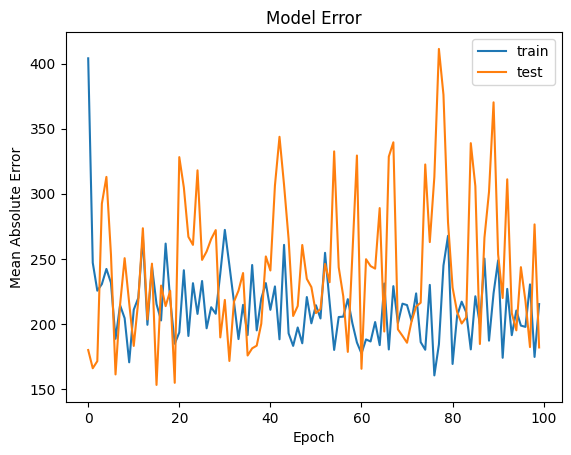

In [4]:
# Graph the Mean Absolute Error (MAE) for training and test sets
import matplotlib.pyplot as plt 

plt.plot(model_history.history['mae'])
plt.plot(model_history.history['val_mae'])
plt.legend(['train', 'test'], loc='upper right')
plt.title('Model Error')
plt.ylabel('Mean Absolute Error')
plt.xlabel('Epoch')
plt.show()


In [22]:
import numpy as np

# create numpy array of random numbers as new variable to test new model
randnums = np.random.randint(1, 30, size=(500, 5))

# convert new variables to list
list = randnums.tolist()

# run new variables through model
prediction = model.predict(list)

16/16 [==============================] - 0s 2ms/step


In [23]:
# output model predictions 
print('Total Crime reported per 1 million resident would be:', prediction)

Total Crime reported per 1 million resident would be: [[338.42685 ]
 [ 57.58531 ]
 [ 71.10417 ]
 [436.91895 ]
 [403.32617 ]
 [462.78958 ]
 [432.69562 ]
 [119.94272 ]
 [575.05554 ]
 [403.97504 ]
 [141.68968 ]
 [341.35333 ]
 [269.11703 ]
 [232.04596 ]
 [507.0362  ]
 [234.05879 ]
 [571.84357 ]
 [262.17972 ]
 [316.83774 ]
 [235.2741  ]
 [402.29346 ]
 [180.27048 ]
 [692.9162  ]
 [356.27826 ]
 [269.78717 ]
 [503.48584 ]
 [342.99216 ]
 [563.3289  ]
 [503.02484 ]
 [219.56831 ]
 [517.89484 ]
 [376.02484 ]
 [338.46027 ]
 [312.5833  ]
 [234.99077 ]
 [318.2111  ]
 [325.12085 ]
 [353.6129  ]
 [367.13812 ]
 [634.30914 ]
 [340.6893  ]
 [664.41376 ]
 [616.77167 ]
 [177.49307 ]
 [ 77.10435 ]
 [426.94235 ]
 [ 43.479927]
 [401.54916 ]
 [363.02234 ]
 [257.5162  ]
 [473.5973  ]
 [562.58356 ]
 [486.00824 ]
 [418.95578 ]
 [455.1     ]
 [245.78453 ]
 [241.65958 ]
 [254.6439  ]
 [311.2198  ]
 [457.8344  ]
 [160.66017 ]
 [339.53986 ]
 [385.41757 ]
 [264.04053 ]
 [256.64505 ]
 [341.27173 ]
 [405.761   ]
 [383.52